In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load cleaned dataset
file_path = "cleaned data.xlsx"
df = pd.read_excel(file_path, header=[0, 1])

In [2]:
# Carry forward top headers for 'Unnamed' columns
new_cols = []
last = None
for top, sub in df.columns:
    if str(top).startswith("Unnamed") or str(top).lower() == "nan":
        top = last
    else:
        last = top
    new_cols.append((top, str(sub)))
df.columns = pd.MultiIndex.from_tuples(new_cols)

In [3]:
# Parse Dates
date_col = next((c for c in df.columns if str(c[1]).strip().lower() in ("dates","date")), df.columns[0])
dates = pd.to_datetime(df[date_col], errors="coerce")

df_clean = pd.DataFrame({"Date": dates}).dropna(subset=["Date"])

/var/folders/bp/_8f43ym16hqfzk9rkpjwxfbc0000gn/T/ipykernel_17488/1674922616.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(df[date_col], errors="coerce")


In [4]:
# Extract Sentiment & Prices
sent_map = {}
price_map = {}

for top, sub in df.columns:
    if (top, sub) == date_col:
        continue

    # Sentiment
    if "SENTIMENT" in str(sub).upper():
        sent_map[top] = f"{top}_Sentiment"
        df_clean[sent_map[top]] = pd.to_numeric(df[(top, sub)], errors="coerce")

    # Prices: 
    if sub in ["Last Price", "Last Price (USD)"]:
        if top not in price_map:
            price_map[top] = f"{top}_Price"
            df_clean[price_map[top]] = pd.to_numeric(df[(top, sub)], errors="coerce")

In [5]:
#Weekly Averages
df_weekly = df_clean.set_index("Date").resample("W").mean(numeric_only=True).reset_index()

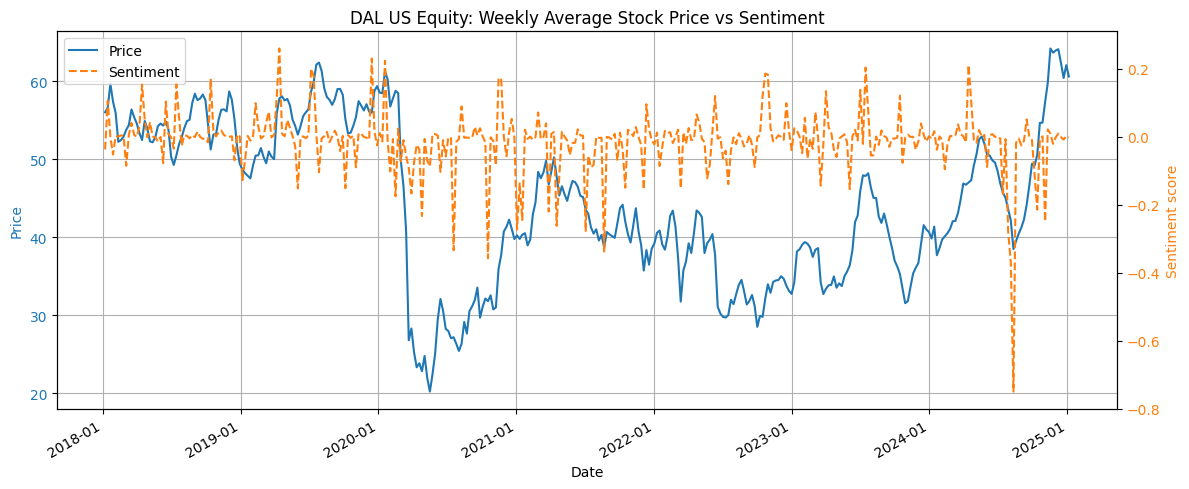

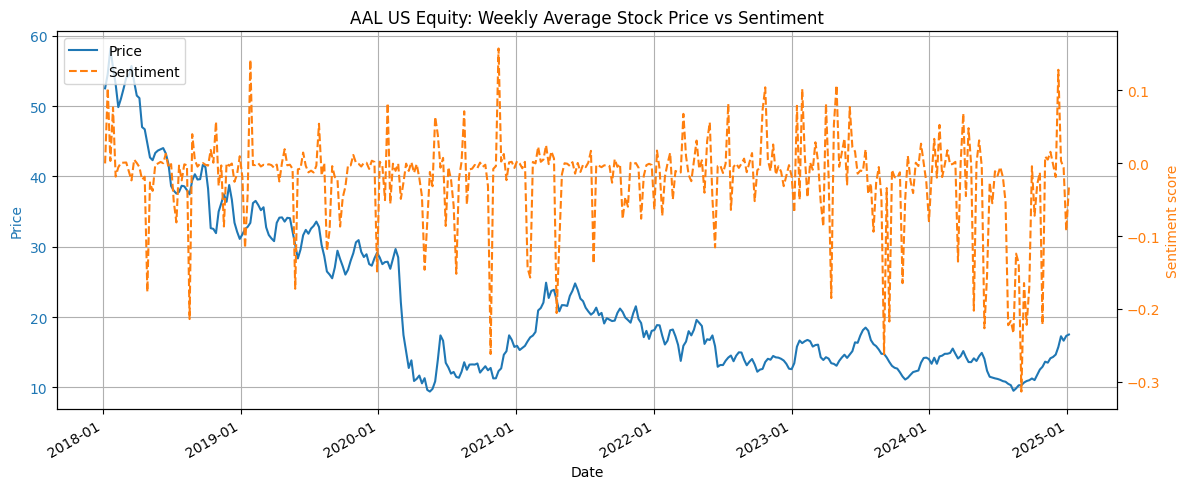

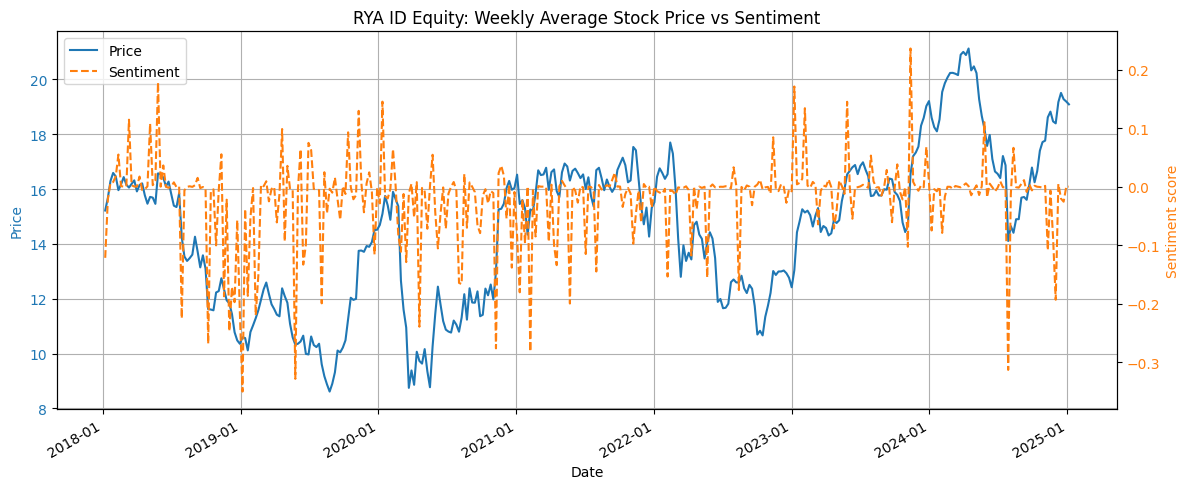

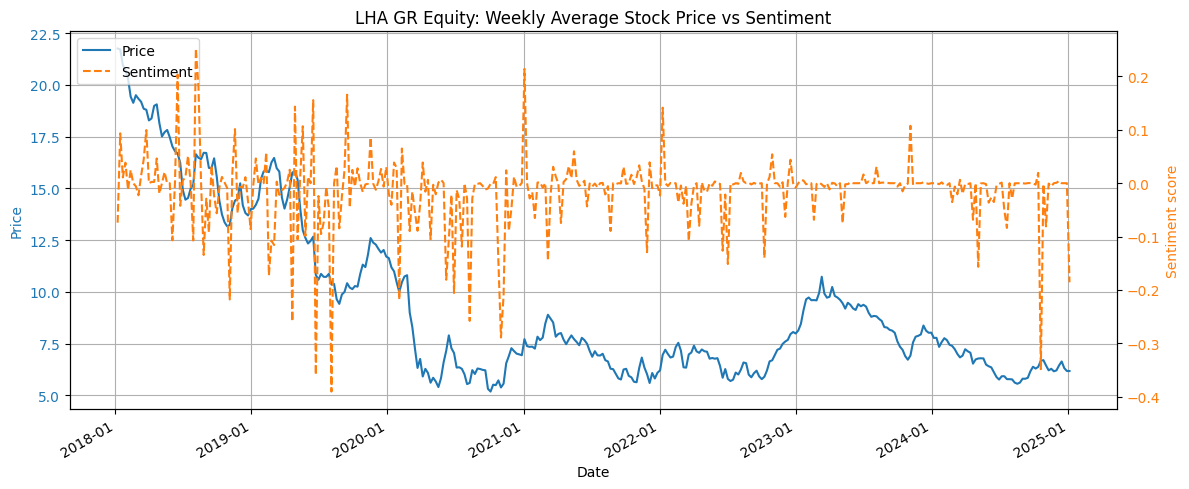

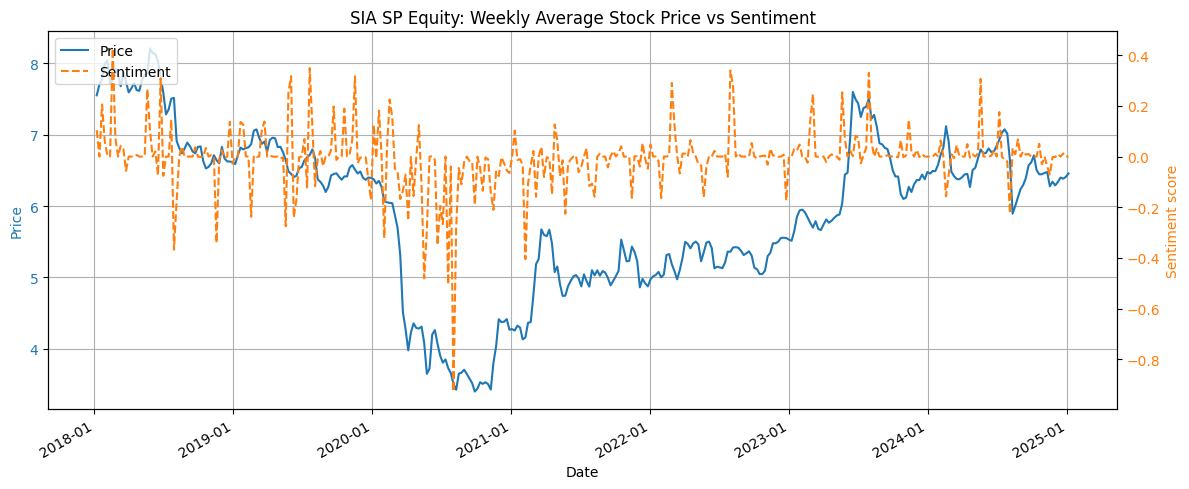

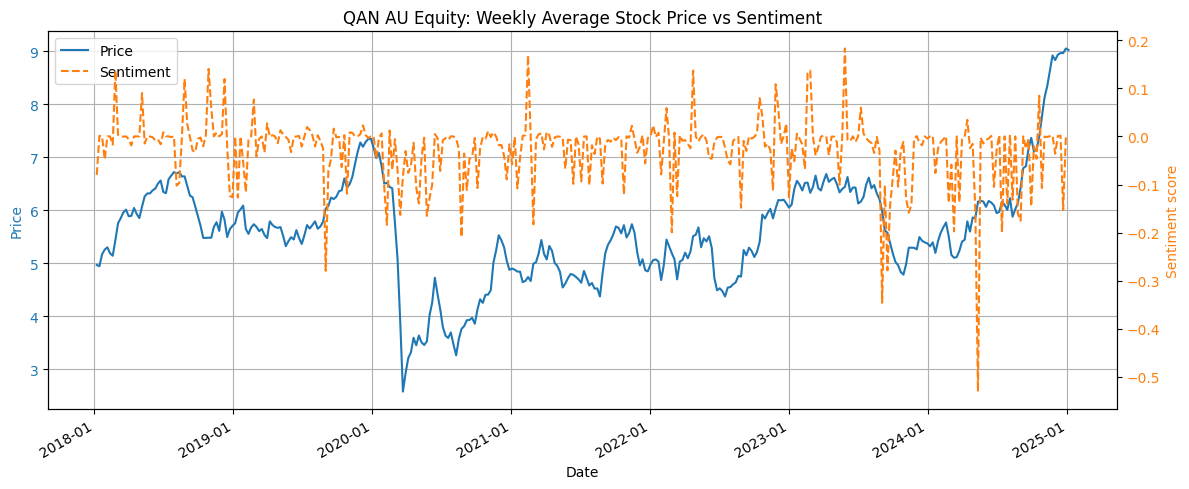

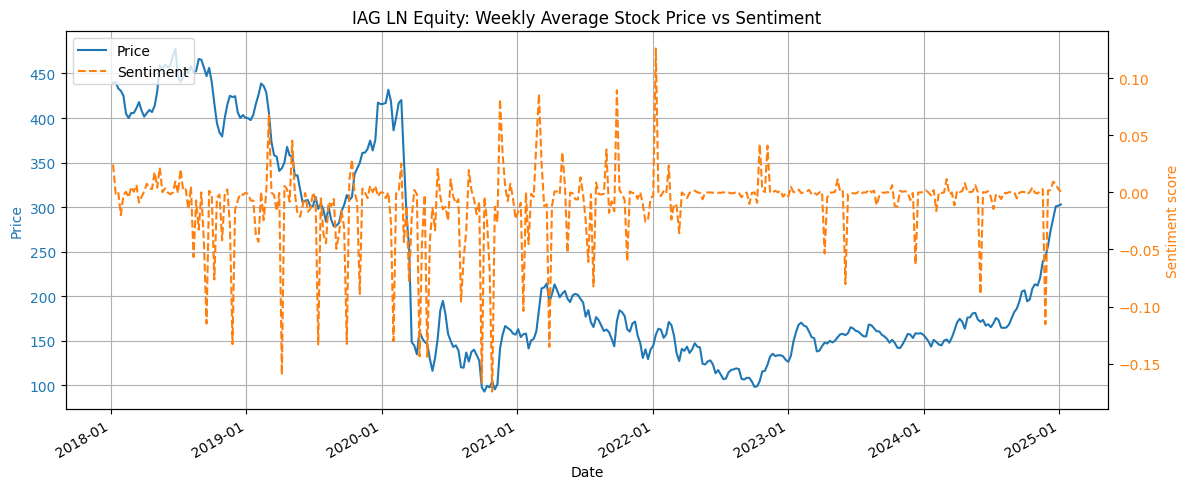

In [6]:
#Weekly Average Stock Price vs Sentiment Plot
for ticker in sent_map.keys():
    if ticker in price_map:  # Only airlines with both
        pcol = price_map[ticker]
        scol = sent_map[ticker]

        fig, ax1 = plt.subplots(figsize=(12, 5))

        # Stock price 
        ax1.plot(df_weekly["Date"], df_weekly[pcol], color="tab:blue", label="Price")
        ax1.set_ylabel("Price", color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")
        ax1.set_xlabel("Date")
        ax1.grid(True)

        # Format x-axis dates
        ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        fig.autofmt_xdate()

        # Sentiment 
        ax2 = ax1.twinx()
        ax2.plot(df_weekly["Date"], df_weekly[scol], color="tab:orange", linestyle="--", label="Sentiment")
        ax2.set_ylabel("Sentiment score", color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange")

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc="upper left")

        plt.title(f"{ticker}: Weekly Average Stock Price vs Sentiment")
        fig.tight_layout()
        plt.show()

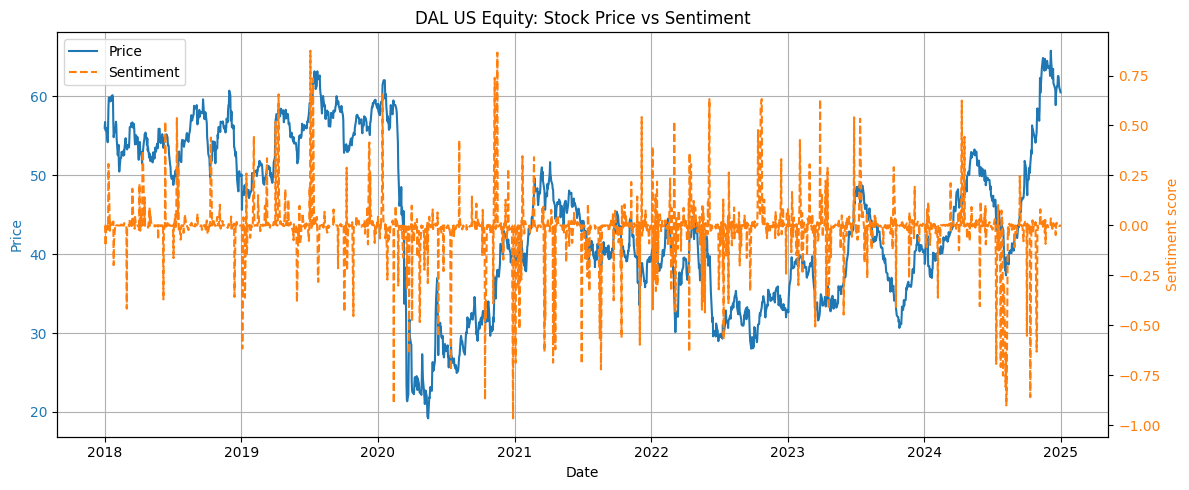

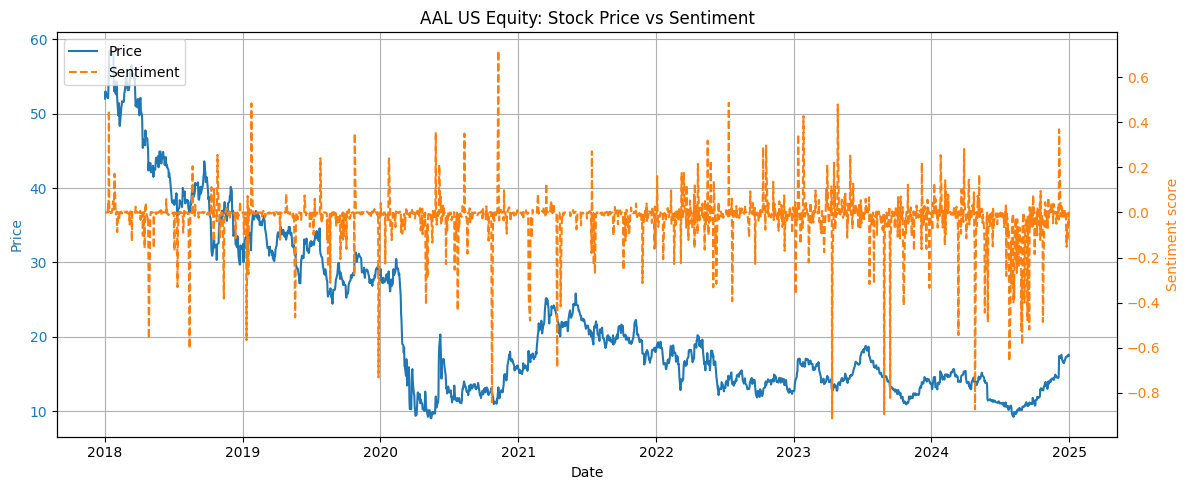

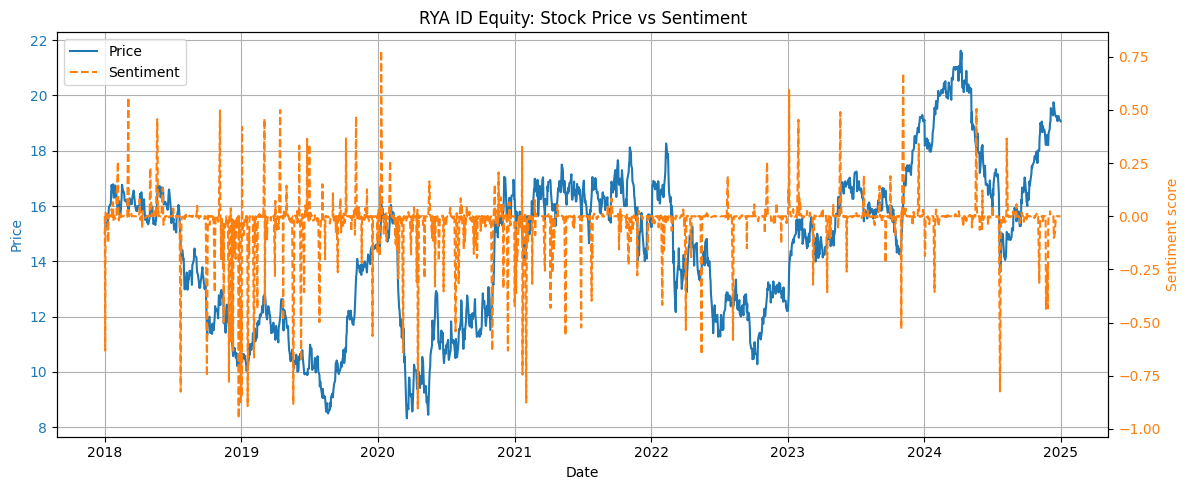

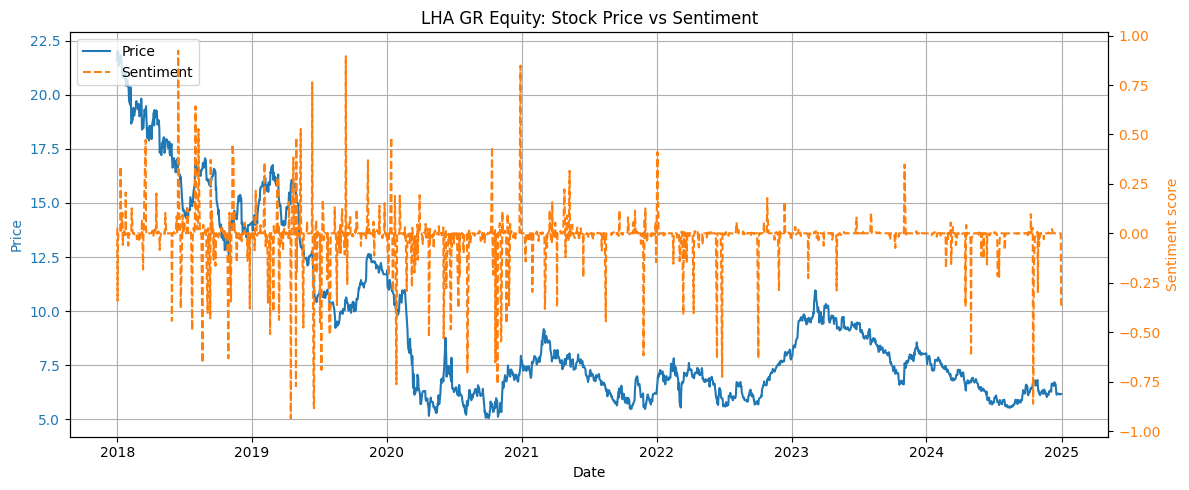

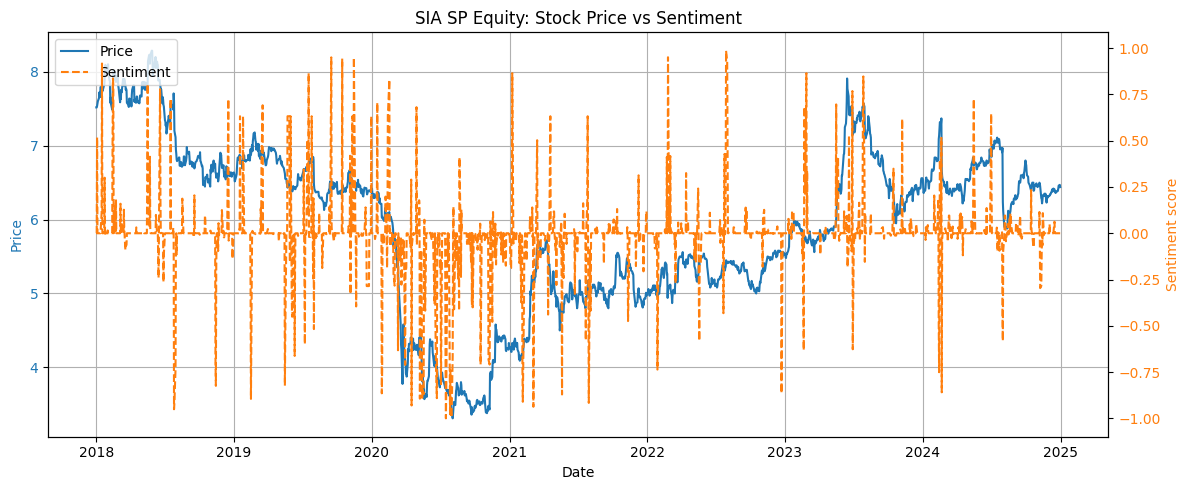

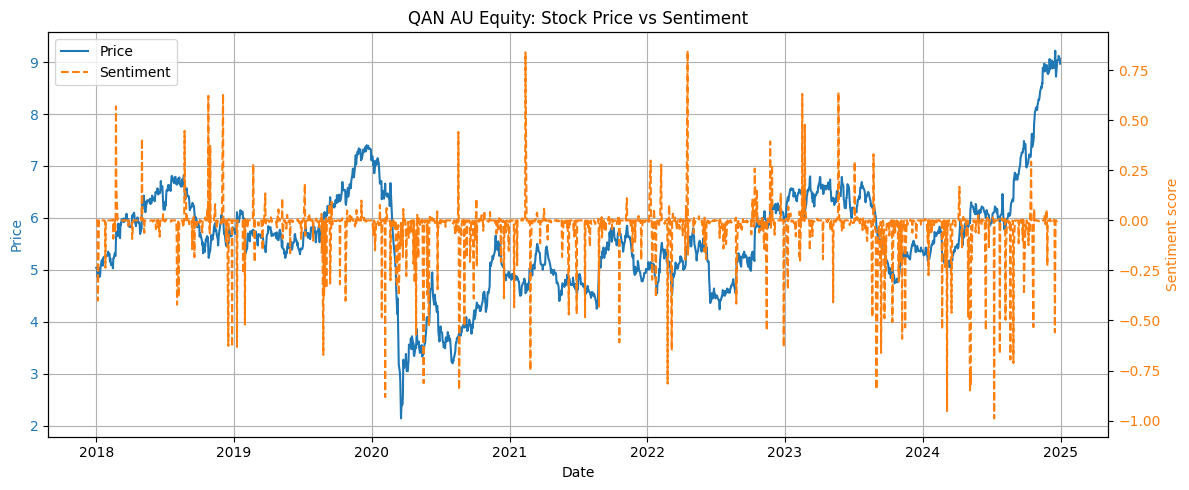

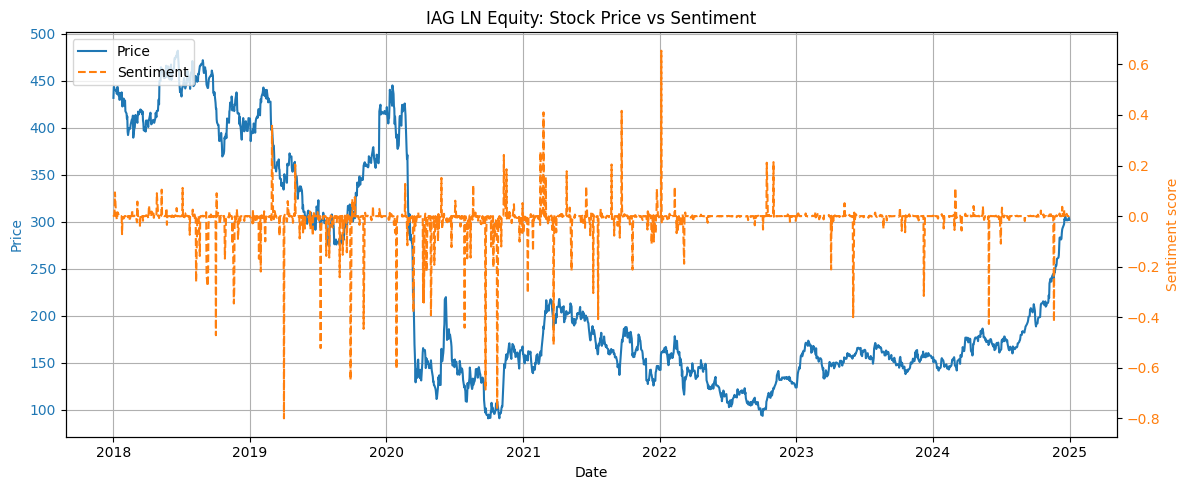

In [8]:
# Weekly Average Stock Price vs Sentiment Plot
for ticker in sent_map.keys():
    if ticker in price_map:  # Only airlines with both
        pcol = price_map[ticker]
        scol = sent_map[ticker]

        fig, ax1 = plt.subplots(figsize=(12, 5))

        # Stock price 
        ax1.plot(df_clean["Date"], df_clean[pcol], color="tab:blue", label="Price")
        ax1.set_ylabel("Price", color="tab:blue")
        ax1.tick_params(axis="y", labelcolor="tab:blue")
        ax1.set_xlabel("Date")
        ax1.grid(True)

        import matplotlib.dates as mdates

        # Format x-axis
        ax1.xaxis.set_major_locator(mdates.YearLocator())   
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


        # Sentiment 
        ax2 = ax1.twinx()
        ax2.plot(df_clean["Date"], df_clean[scol], color="tab:orange", linestyle="--", label="Sentiment")
        ax2.set_ylabel("Sentiment score", color="tab:orange")
        ax2.tick_params(axis="y", labelcolor="tab:orange")

        # Combine legends
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc="upper left")

        plt.title(f"{ticker}: Stock Price vs Sentiment")
        fig.tight_layout()
        plt.show()

In [10]:
import seaborn as sns

#Define key event periods (final, updated with new events) ===
events = [
    # Pre-COVID
    ("2018-07-01", "2018-12-31", "US-China Trade War Tariffs", "khaki"),
    ("2018-09-01", "2018-09-30", "Ryanair Pilot Strikes (Europe)", "darkorange"),
    ("2019-03-01", "2019-12-31", "Boeing 737 MAX Grounding", "sandybrown"),
    ("2019-09-01", "2019-09-30", "Thomas Cook Collapse", "lightcoral"),
    ("2019-06-01", "2019-12-31", "Flight Shame Movement (Europe)", "plum"),

    # COVID Era
    ("2020-03-01", "2020-06-30", "COVID-19 First Wave", "red"),
    ("2020-03-11", "2020-04-30", "WHO Pandemic Decl. / Lockdowns", "salmon"),
    ("2020-04-01", "2020-06-30", "Oil Price Crash (WTI < 0)", "peru"),
    ("2020-04-01", "2021-06-30", "Global Travel Restrictions", "lightgrey"),

    # Variants & Recovery
    ("2021-01-01", "2021-06-30", "Vaccine Rollouts", "gold"),
    ("2021-07-01", "2021-10-31", "Delta Variant", "royalblue"),
    ("2021-11-01", "2022-03-31", "Omicron Variant", "tomato"),

    # Geopolitics & Fuel
    ("2022-02-24", "2022-06-30", "Russia-Ukraine War (start)", "deepskyblue"),
    ("2022-03-01", "2022-09-30", "Oil Price Spike / Jet Fuel Shortage", "navajowhite"),

    # Recovery
    ("2023-01-01", "2023-06-30", "China Reopens Travel", "limegreen"),
    ("2023-01-11", "2023-01-20", "US FAA System Outage", "orchid"),
    ("2023-10-01", "2024-03-31", "Middle East Conflict (Israel-Hamas)", "thistle"),

    # Climate / Weather
    ("2023-06-01", "2023-09-30", "Heatwaves & Wildfires (NA & EU)", "palegoldenrod"),
    ("2024-01-01", "2024-01-31", "Severe Winter Storms (US/EU)", "steelblue"),
    ("2024-06-01", "2024-06-30", "Record Jet Fuel Prices", "orange"),
    ("2024-07-01", "2024-07-31", "European ATC Strikes", "mediumslateblue")
]

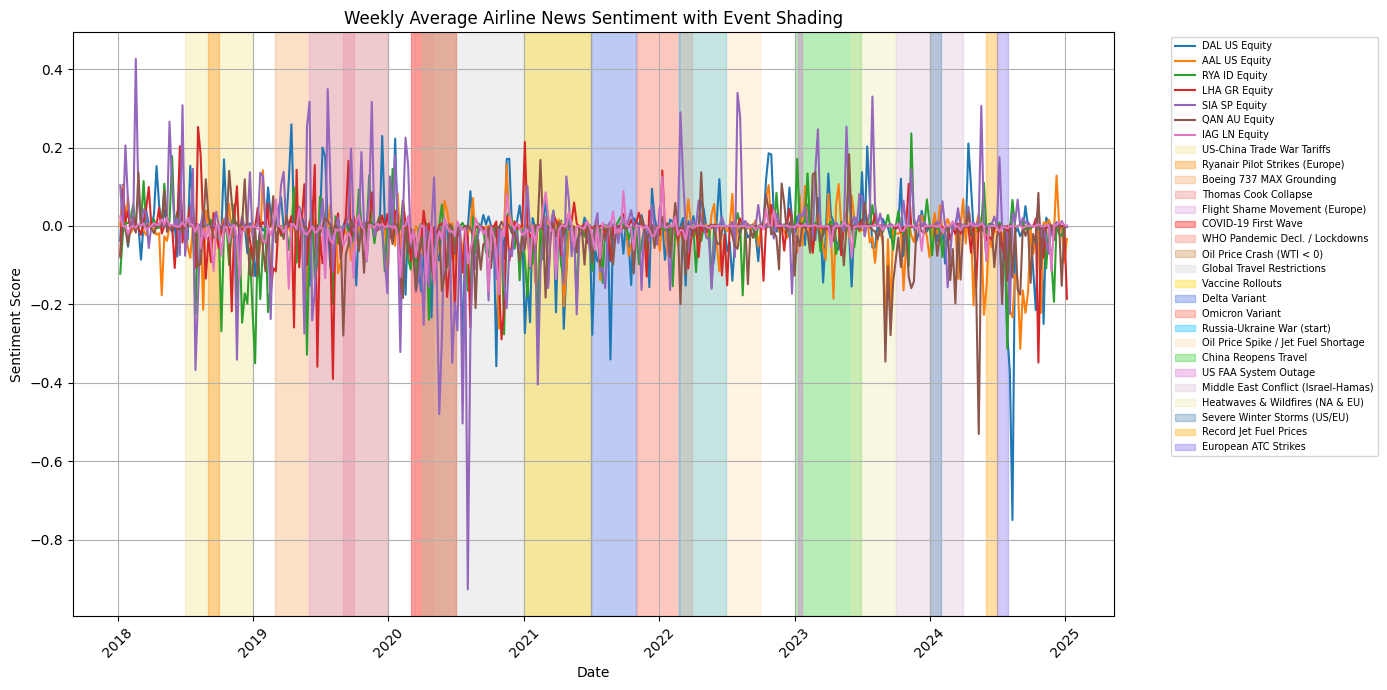

In [14]:
# Plot sentiment with shaded regions ===
plt.figure(figsize=(14,7))
for t in [c for c in df_weekly.columns if c.endswith("_Sentiment")]:
    plt.plot(df_weekly["Date"], df_weekly[t], label=t.replace("_Sentiment",""))

for start, end, label, color in events:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                color=color, alpha=0.35, label=label)
plt.title("Weekly Average Airline News Sentiment with Event Shading")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.grid(True)
ax = plt.gca()
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

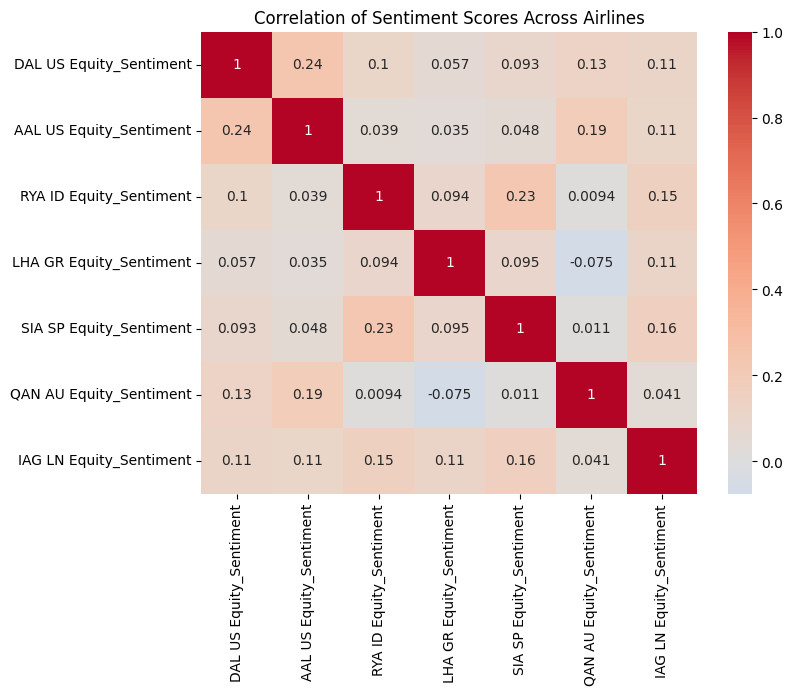

In [12]:
# Heatmap of correlations (sentiment vs sentiment)
sent_only = df_weekly[[c for c in df_weekly.columns if c.endswith("_Sentiment")]]
plt.figure(figsize=(8,6))
sns.heatmap(sent_only.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Sentiment Scores Across Airlines")
plt.show()

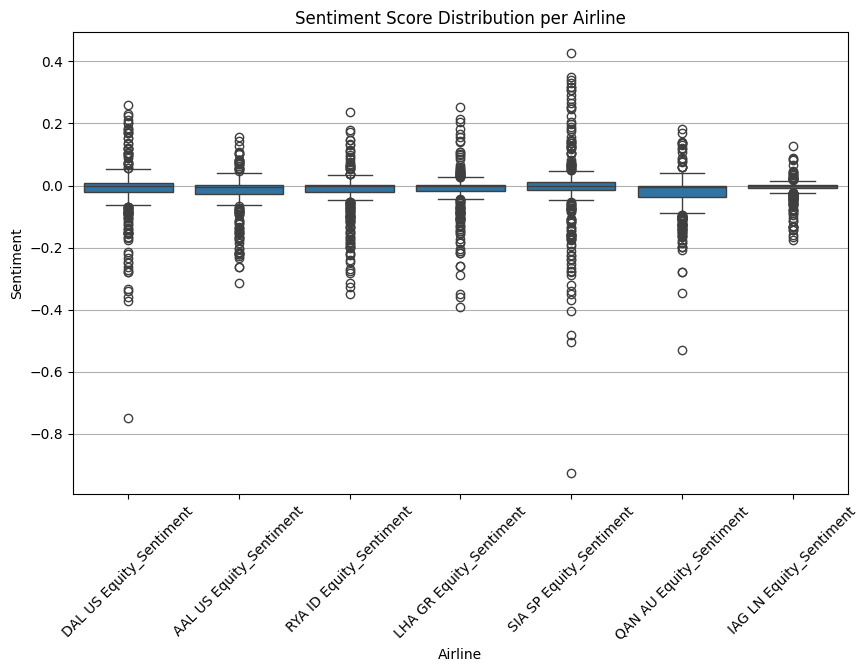

In [13]:
#Distribution (Boxplot)
sent_melt = df_weekly.melt(
    id_vars="Date", 
    value_vars=[c for c in df_weekly.columns if c.endswith("_Sentiment")],
    var_name="Airline", 
    value_name="Sentiment"
)
plt.figure(figsize=(10,6))
sns.boxplot(x="Airline", y="Sentiment", data=sent_melt)
plt.title("Sentiment Score Distribution per Airline")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

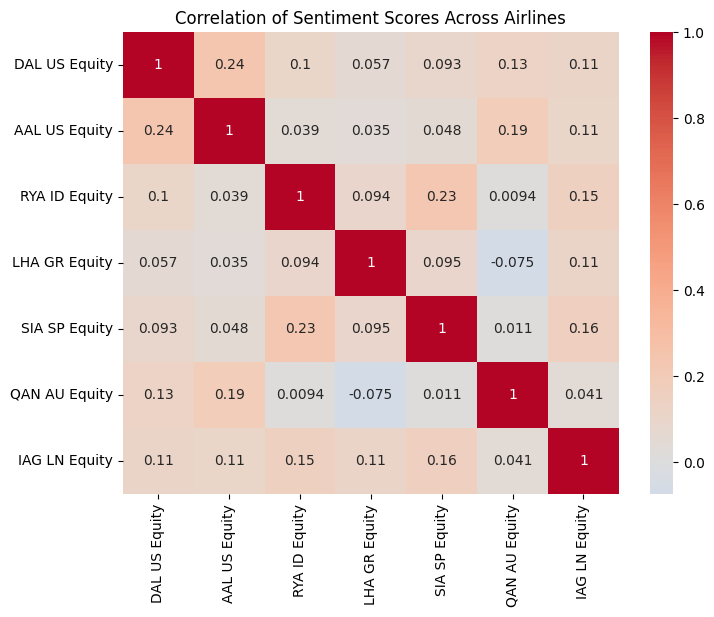

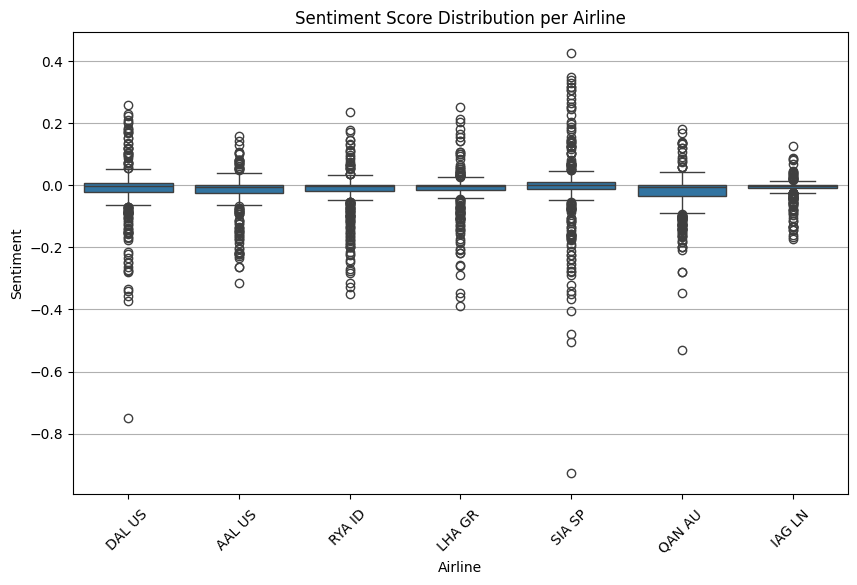

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Heatmap of correlations (sentiment vs sentiment) ===
sent_only = df_weekly[[c for c in df_weekly.columns if c.endswith("_Sentiment")]]
# Rename columns (remove "_Sentiment")
sent_renamed = sent_only.rename(columns=lambda x: x.replace("_Sentiment", ""))

plt.figure(figsize=(8,6))
sns.heatmap(sent_renamed.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Sentiment Scores Across Airlines")
plt.show()


# === Distribution (Boxplot) ===
sent_melt = df_weekly.melt(
    id_vars="Date", 
    value_vars=[c for c in df_weekly.columns if c.endswith("_Sentiment")],
    var_name="Airline", 
    value_name="Sentiment"
)

# Clean the 'Airline' column (remove "_Sentiment")
sent_melt["Airline"] = sent_melt["Airline"].str.replace("Equity_Sentiment", "", regex=False)

plt.figure(figsize=(10,6))
sns.boxplot(x="Airline", y="Sentiment", data=sent_melt)
plt.title("Sentiment Score Distribution per Airline")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()


In [16]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

results = []

# --- Find tickers that have both sentiment and price ---
overlap = [s for s in sent_map.values() if s.replace("_Sentiment","_Price") in df_clean.columns]

if not overlap:
    print("No airlines with both price & sentiment found.")
else:
    for s in overlap:
        ticker = s.replace("_Sentiment","")
        pcol = f"{ticker}_Price"
        scol = f"{ticker}_Sentiment"

        tmp = df_clean[["Date", pcol, scol]].dropna()

        # Define regression: Price ~ Sentiment
        X = sm.add_constant(tmp[scol])  # add intercept
        y = tmp[pcol]

        model = sm.OLS(y, X).fit()
        results.append(model)

        print(f"\n=== {ticker} ===")
        print(model.summary())

    reg_table = summary_col(
        results,
        stars=True,
        float_format='%0.4f',
        model_names=[s.replace("_Sentiment","") for s in overlap],
        info_dict={'N': lambda x: f"{int(x.nobs)}",
                   'R2': lambda x: f"{x.rsquared:.3f}"}
    )
    print(reg_table)


=== DAL US Equity ===
                             OLS Regression Results                            
Dep. Variable:     DAL US Equity_Price   R-squared:                       0.010
Model:                             OLS   Adj. R-squared:                  0.010
Method:                  Least Squares   F-statistic:                     19.04
Date:                 Thu, 21 Aug 2025   Prob (F-statistic):           1.35e-05
Time:                         21:34:18   Log-Likelihood:                -6804.2
No. Observations:                 1827   AIC:                         1.361e+04
Df Residuals:                     1825   BIC:                         1.362e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002558. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== DAL US Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                619.292
Distribution:                  Normal   AIC:                          -1230.58
Method:            Maximum Likelihood   BIC:                          -1214.98
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:43   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.3812e-03  2.445e-03

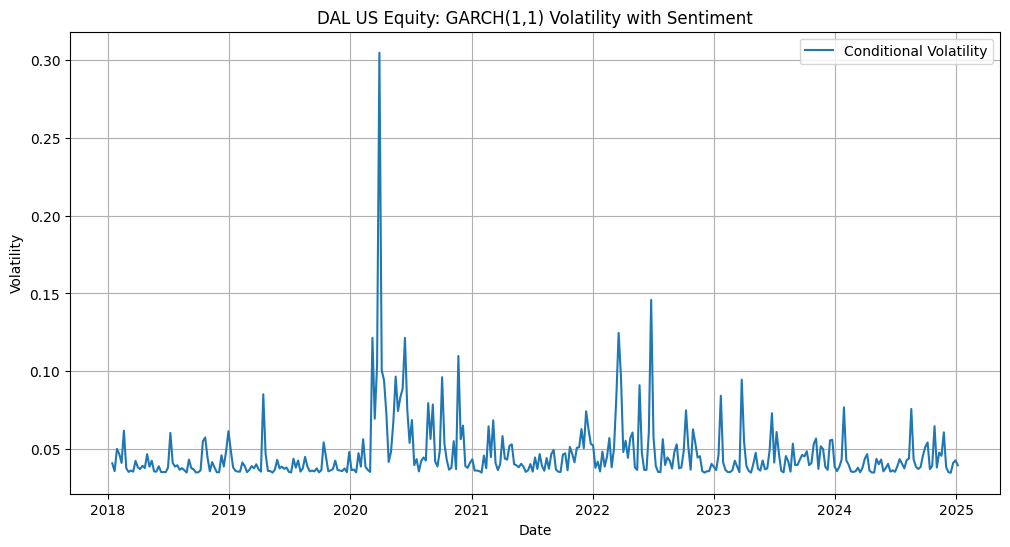

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.003688. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== AAL US Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                534.783
Distribution:                  Normal   AIC:                          -1061.57
Method:            Maximum Likelihood   BIC:                          -1045.97
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:44   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -3.5085e-03  2.902

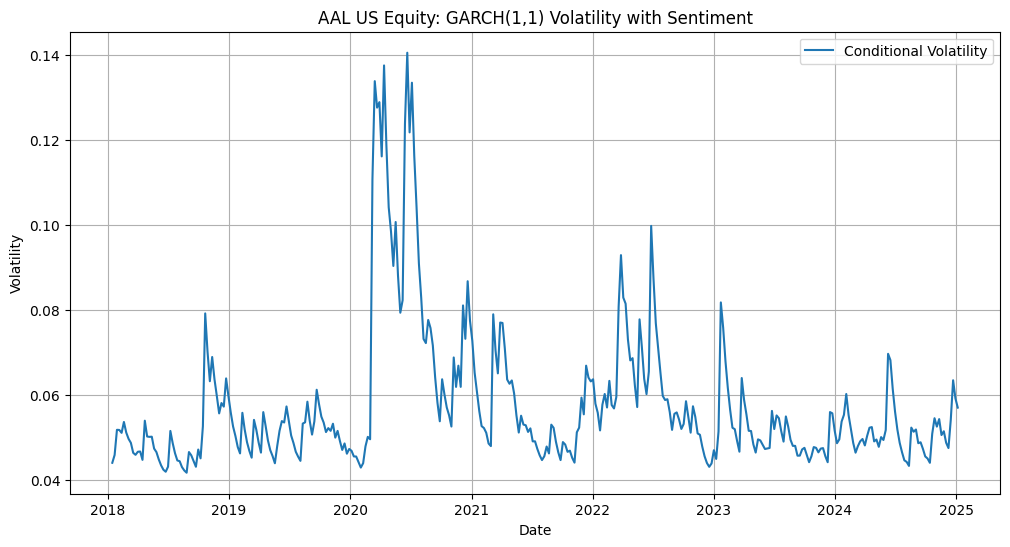

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00203. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== RYA ID Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                631.391
Distribution:                  Normal   AIC:                          -1254.78
Method:            Maximum Likelihood   BIC:                          -1239.18
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:45   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.5486e-03  2.405e-03

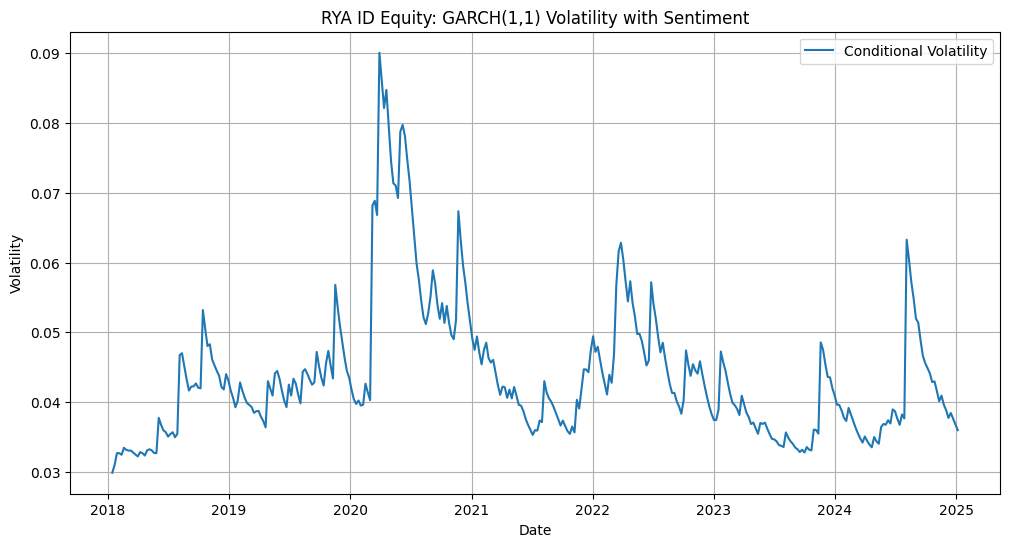

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002035. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== LHA GR Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                635.471
Distribution:                  Normal   AIC:                          -1262.94
Method:            Maximum Likelihood   BIC:                          -1247.34
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:46   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -3.9990e-03  2.165

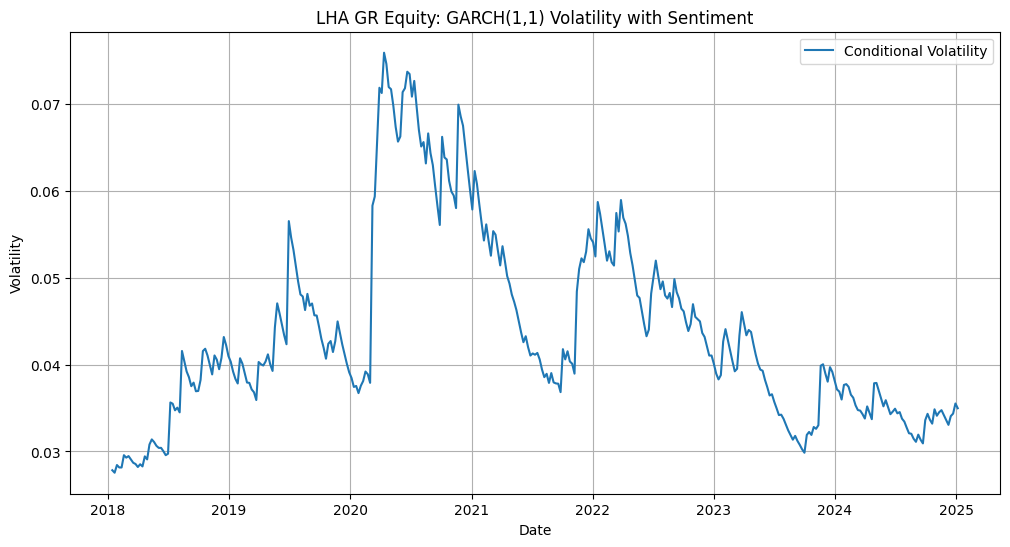

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0008088. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== SIA SP Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                828.694
Distribution:                  Normal   AIC:                          -1649.39
Method:            Maximum Likelihood   BIC:                          -1633.79
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:46   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         3.9825e-04  1.314e-03

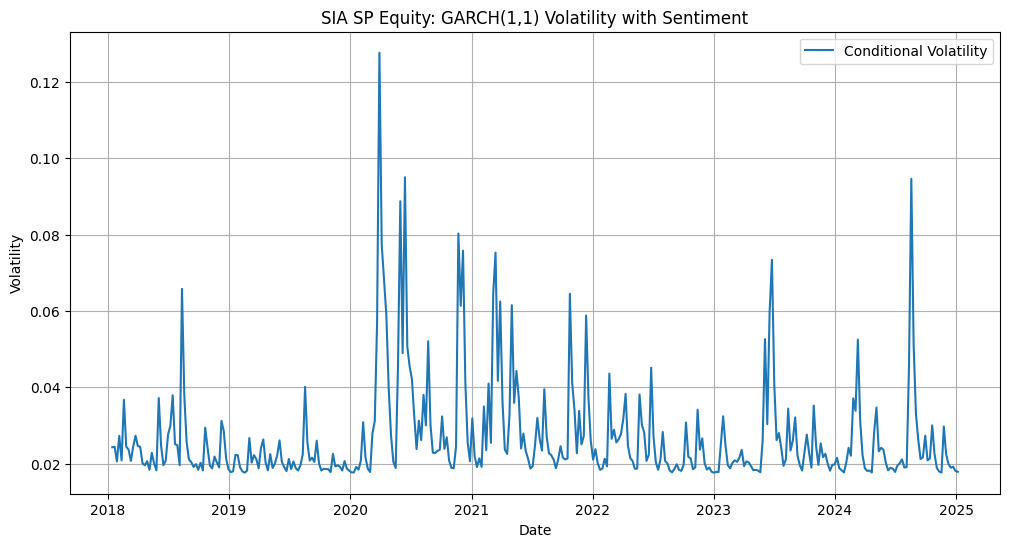

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001934. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== QAN AU Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                701.740
Distribution:                  Normal   AIC:                          -1395.48
Method:            Maximum Likelihood   BIC:                          -1379.88
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:47   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         3.7130e-03  1.768e-03   

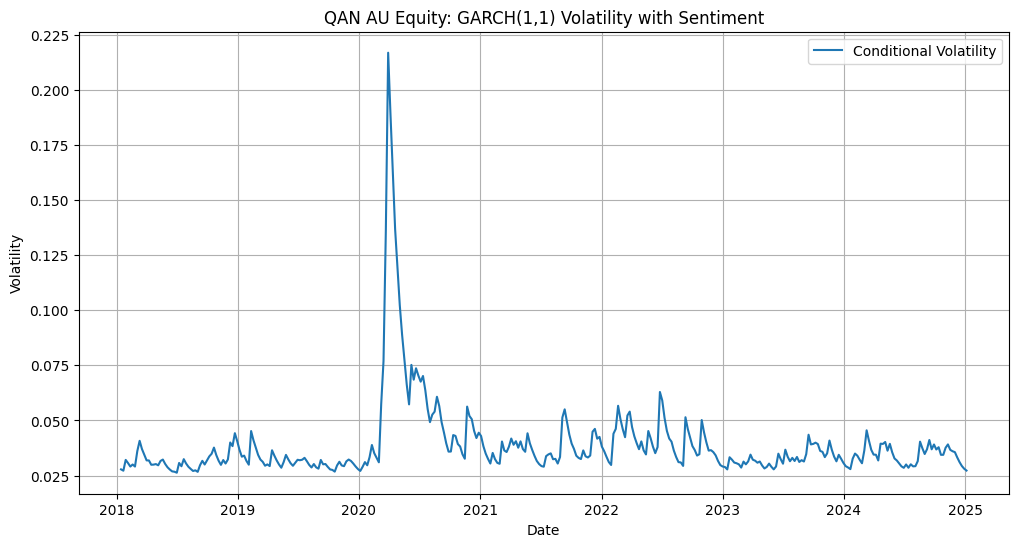

/Users/TuAnh/miniconda3/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00388. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(



=== IAG LN Equity ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                578.362
Distribution:                  Normal   AIC:                          -1148.72
Method:            Maximum Likelihood   BIC:                          -1133.13
                                        No. Observations:                  365
Date:                Thu, Aug 21 2025   Df Residuals:                      364
Time:                        21:36:47   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.3614e-03  2.214e-03

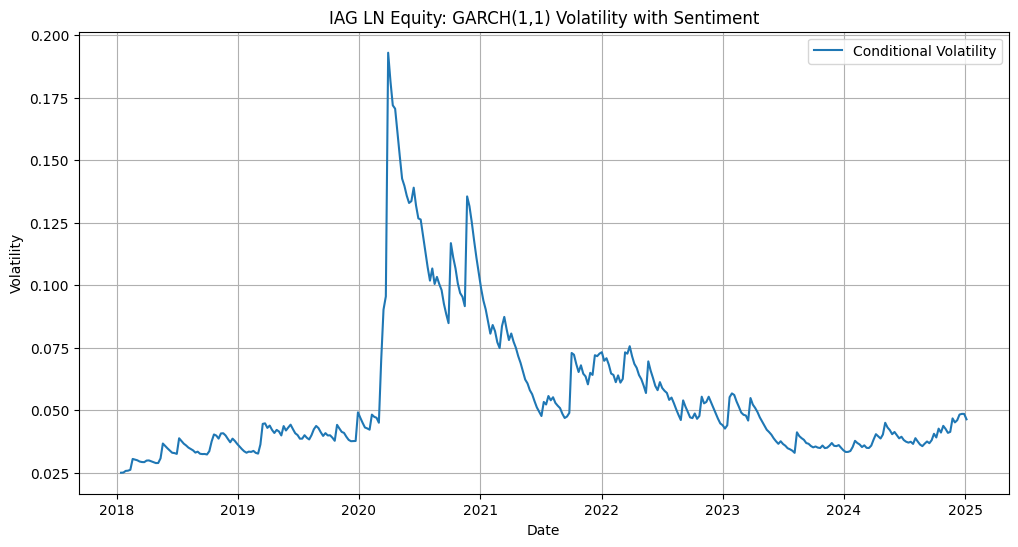

In [18]:
import numpy as np
from arch import arch_model

garch_results = {}


for ticker in sent_map.keys():
    if ticker not in price_map:
        continue
    
    pcol = price_map[ticker]
    scol = sent_map[ticker]

    tmp = df_weekly[["Date", pcol, scol]].dropna()
    if tmp.empty:
        continue

    # Log returns
    tmp["Return"] = np.log(tmp[pcol]).diff()
    tmp = tmp.dropna()

    if tmp["Return"].var() == 0:  # skip if flat
        continue

    # Align sentiment as exogenous regressor 
    exog = tmp[scol].iloc[1:].values if len(tmp[scol]) > len(tmp["Return"]) else tmp[scol].values
    exog = exog[:len(tmp["Return"])]

    # Fit GARCH(1,1) with sentiment
    model = arch_model(tmp["Return"], vol="GARCH", p=1, q=1,
                       mean="Constant", x=exog, dist="normal")
    res = model.fit(disp="off")
    garch_results[ticker] = res

    # Print summary
    print(f"\n=== {ticker} ===")
    print(res.summary())

    # Plot conditional volatility
    plt.figure(figsize=(12,6))
    plt.plot(tmp["Date"], res.conditional_volatility, label="Conditional Volatility")
    plt.title(f"{ticker}: GARCH(1,1) Volatility with Sentiment")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    plt.grid(True)
    plt.show()

In [18]:
import pandas as pd

# Table of results
rows = []
for ticker, res in garch_results.items():
    params = res.params
    
    # Extract ARCH(1) and GARCH(1) terms
    alpha = params.get("alpha[1]", float("nan"))
    beta = params.get("beta[1]", float("nan"))
    persistence = alpha + beta
    
    rows.append({
        "Ticker": ticker,
        "Alpha (α)": alpha,
        "Beta (β)": beta,
        "Persistence (α+β)": persistence
    })

# Create DataFrame
vol_persistence_df = pd.DataFrame(rows)

# Round for readability
vol_persistence_df = vol_persistence_df.round(4)

# Display neatly
print(vol_persistence_df)

# If you want a nicer Jupyter output
display(vol_persistence_df)

# Optional: save to CSV for later use
vol_persistence_df.to_csv("volatility_persistence.csv", index=False)

          Ticker  Alpha (α)  Beta (β)  Persistence (α+β)
0  DAL US Equity     0.5106    0.0819             0.5925
1  AAL US Equity     0.1606    0.7150             0.8755
2  RYA ID Equity     0.0818    0.8517             0.9335
3  LHA GR Equity     0.0638    0.9113             0.9750
4  SIA SP Equity     0.5709    0.2471             0.8179
5  QAN AU Equity     0.1984    0.6925             0.8909
6  IAG LN Equity     0.1000    0.8800             0.9800


,Ticker,Alpha (α),Beta (β),Persistence (α+β)
0,DAL US Equity,0.5106,0.0819,0.5925
1,AAL US Equity,0.1606,0.7150,0.8755
2,RYA ID Equity,0.0818,0.8517,0.9335
3,LHA GR Equity,0.0638,0.9113,0.9750
4,SIA SP Equity,0.5709,0.2471,0.8179
5,QAN AU Equity,0.1984,0.6925,0.8909
6,IAG LN Equity,0.1000,0.8800,0.9800
